# **Import Libraries**

In [78]:
!pip install --upgrade scikit-learn
!pip install --upgrade scikit-learn xgboost
!pip install xgboost
!pip install pyspellchecker
!pip install streamlit
!pip install streamlit pyngrok
!pip install streamlit pyngrok joblib scikit-learn
!pip install contractions
!pip install better_profanity
!pip install symspellpy
!pip install better_profanity
!pip install profanity-check
!pip install hatesonar
!pip install --upgrade joblib
!pip install strsimpy
!pip install autocorrect
!pip install fuzzywuzzy
!pip install symspellcpppy

In [79]:
import pandas as pd
import nltk
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import streamlit as st
import contractions
import pkg_resources
import sys
import contractions
import json

In [80]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder,  MaxAbsScaler
from spellchecker import SpellChecker
from IPython import get_ipython
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as stats
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from better_profanity import profanity
from symspellpy import SymSpell, Verbosity
from nltk import pos_tag
from scipy.sparse import hstack, csr_matrix
from textblob import TextBlob
from hatesonar import Sonar
from fuzzywuzzy import process
import matplotlib.pyplot as plt

In [81]:
import re
import string
import nltk
import contractions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from contractions import contractions_dict
from autocorrect import Speller

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [82]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

# **Load dataset**

In [83]:
# Load the dataset
file_path = "/content/cyberbullying_tweets.csv"
df = pd.read_csv(file_path)

load profane language

# **Inspecting data**

In [84]:
# Display basic information about the dataset
dataset_info = df.info()
dataset_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


In [85]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

,0
tweet_text,0
cyberbullying_type,0


In [86]:
# Check for duplicate entries
duplicate_entries = df.duplicated().sum()
duplicate_entries

36

In [87]:
# Check for duplicate rows based on the 'tweet_text' column
duplicate_rows = df[df.duplicated(subset=['tweet_text'], keep=False)]
print(f"Total duplicate tweets found: {len(duplicate_rows)}")

Total duplicate tweets found: 3350


In [88]:
df.drop_duplicates(subset=['tweet_text'], keep='first', inplace=True)
# Check how many are left
print("\nAfter dropping duplicates, shape:", df.shape)


After dropping duplicates, shape: (46017, 2)


In [89]:
# Check class distribution
class_distribution = df.iloc[:, -1].value_counts()
class_distribution

,count
cyberbullying_type,
religion,7995
age,7992
ethnicity,7952
not_cyberbullying,7937
gender,7898
other_cyberbullying,6243


In [90]:
df.dropna(subset=['tweet_text'], inplace=True)
print("After dropping missing 'tweet_text', shape:", df.shape)

After dropping missing 'tweet_text', shape: (46017, 2)


#**EDA of the dataset**

In [91]:
import pandas as pd

df = pd.read_csv(file_path)
df_info = df.info()
df_head = df.head()
df_description = df.describe()
missing_values = df.isnull().sum()

df_info, df_head, df_description, missing_values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


(None,
                                           tweet_text cyberbullying_type
 0  In other words #katandandre, your food was cra...  not_cyberbullying
 1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
 2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
 3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
 4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying,
                                                tweet_text cyberbullying_type
 count                                               47692              47692
 unique                                              46017                  6
 top     RT @sailorhg: the intro for my hardware hackin...           religion
 freq                                                    2               7998,
 tweet_text            0
 cyberbullying_type    0
 dtype: int64)

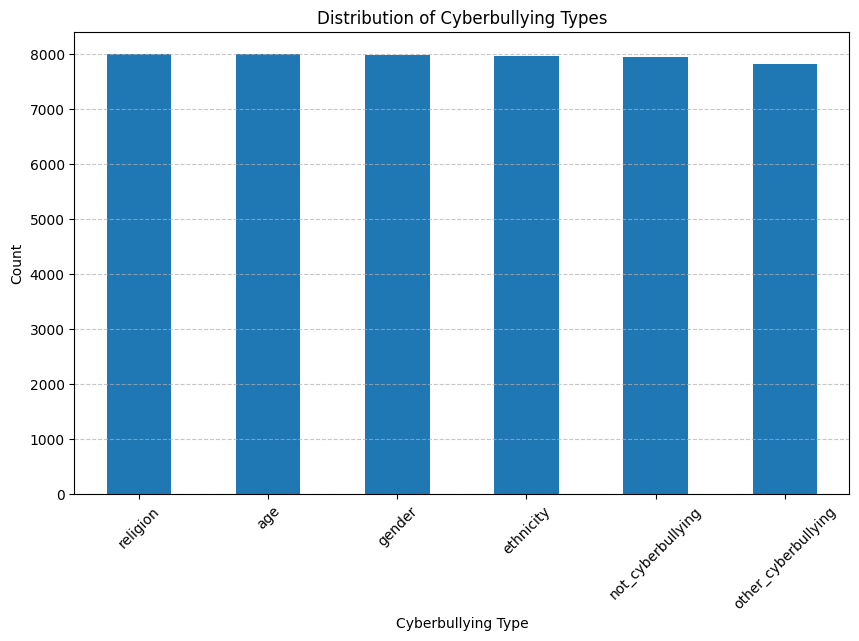

In [92]:
import matplotlib.pyplot as plt

# Visualization 1: Distribution of cyberbullying types
plt.figure(figsize=(10, 6))
df['cyberbullying_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Cyberbullying Types')
plt.xlabel('Cyberbullying Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


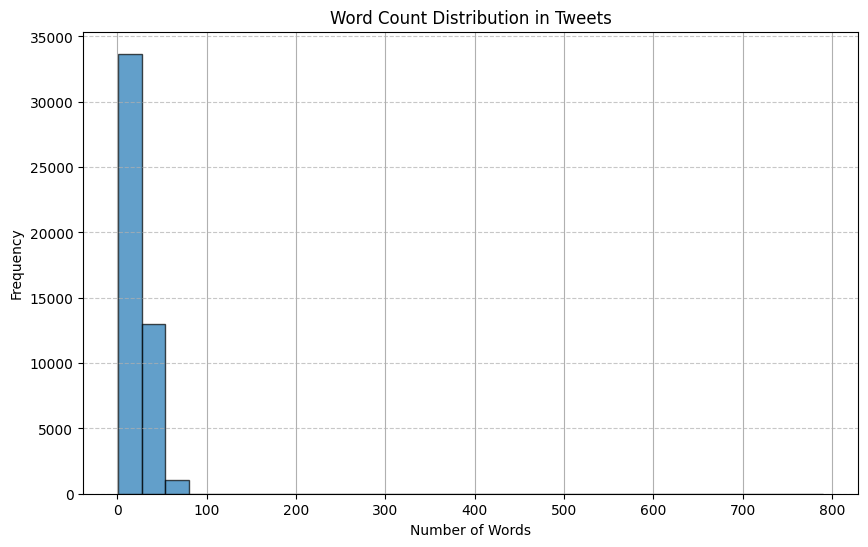

In [93]:
# Visualization 2: Word count distribution in tweets
df['word_count'] = df['tweet_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
df['word_count'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.title('Word Count Distribution in Tweets')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<Figure size 1200x600 with 0 Axes>

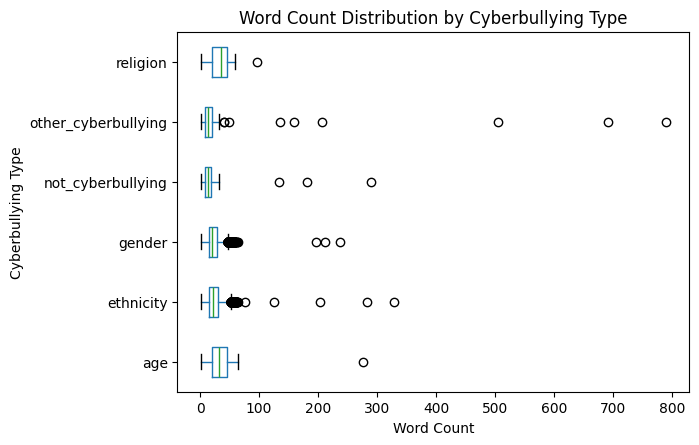

In [94]:
# Visualization 3: Boxplot of word counts by cyberbullying type
plt.figure(figsize=(12, 6))
df.boxplot(column='word_count', by='cyberbullying_type', grid=False, vert=False)
plt.title('Word Count Distribution by Cyberbullying Type')
plt.xlabel('Word Count')
plt.ylabel('Cyberbullying Type')
plt.suptitle('')  # Remove default title
plt.show()


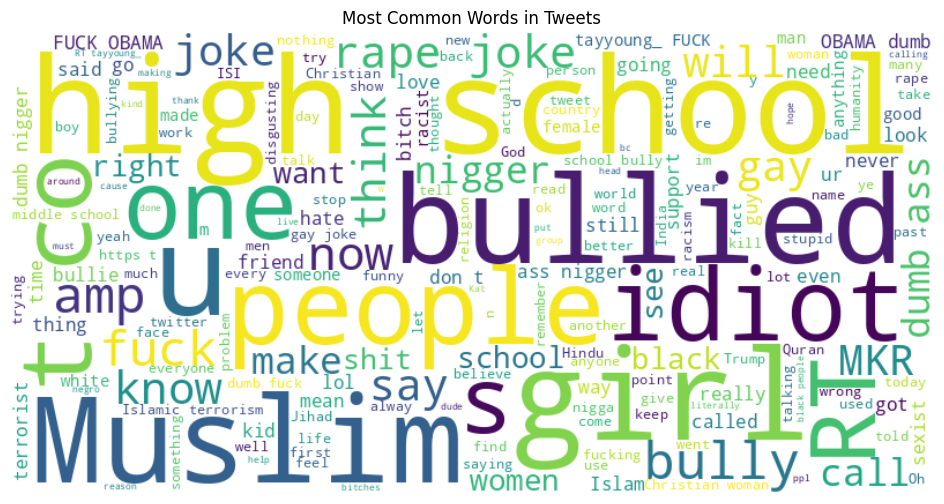

In [95]:
from wordcloud import WordCloud

# Visualization 4: Word cloud of most common words in tweets
text_data = " ".join(df['tweet_text'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Tweets")
plt.show()


# **Preprocessing**

In [96]:
pip install pandas nltk contractions textblob better_profanity fuzzywuzzy symspellpy

In [97]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [98]:
import os # Import the 'os' module at the beginning of your code

# Initialize SymSpell for spell correction (if available)
sym_spell = None
if SymSpell is not None:
    max_edit_distance = 2
    prefix_length = 7
    sym_spell = SymSpell(max_edit_distance, prefix_length)
    dictionary_path = "frequency_dictionary_en_82_765.txt"  # Ensure this file is present in your working directory.
    if os.path.exists(dictionary_path): # Now 'os' is defined and can be used.
        # term_index = 0 (word), count_index = 1 (frequency)
        sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
    else:
        print("Warning: SymSpell dictionary file not found. Spell correction will be skipped.")
        sym_spell = None
else:
    print("Warning: symspellpy package is not installed. Spell correction will be skipped.")

Load and Merge Profane Word Sources

In [99]:
# (a) Download external profane words list from GitHub
# This downloads the JSON file as "words.json" in the current directory.
!wget -O words.json https://raw.githubusercontent.com/zacanger/profane-words/master/words.json

# (b) Hard-coded offensive words set
offensive_words_set = {
    "stupid", "idiot", "loser", "dumb", "ugly",
    "hell", "jerk", "douche", "prick", "scumbag", "wimp",
    "fuck", "bitch", "ass", "dick", "motherfucker", "pussy", "asshole",
    "fatso", "retard", "psycho", "freak", "degenerate", "snowflake",
    "useless", "failure", "disgrace", "disappointment", "crap",
    "damnation", "shut up", "dipshit", "dickhead", "annoying", "weak",
    "motherless", "bigot", "misogynist", "misandrist", "pedo", "incel",
    "tramp", "skank", "cock", "bastard", "shithole",
    "pathetic", "worthless", "embarrassment",
    "clown", "moron", "noob", "joke", "coward",
    "lame", "nuisance", "scum", "kys", "slut", "whore",
    "bimbo", "homewrecker", "pervert", "creep", "groper", "rapist", "molester",
    "sex pest", "sex addict", "dirty minded", "explicit", "horny", "porn",
    "nude", "catcall", "vermin", "cockroach", "rodent", "animal", "parasite", "filth",
    "mongrel", "bottom-feeder", "subhuman", "freakshow", "trash", "garbage",
    "filthy", "disgusting", "crazy", "waste", "terrible"
    "overreacting", "imbecile", "jackass",
    "bonehead", "dimwit", "airhead", "buffoon", "fool", "numbskull", "dunderhead",
    "peabrain", "birdbrain", "nitwit", "dunce", "meathead", "dork", "jerkface",
    "douchebag", "scoundrel", "varmint", "snake", "rat", "troll", "hellspawn",
    "knucklehead", "simpleton", "halfwit", "nincompoop", "blockhead", "lamebrain",
    "schmuck", "twit", "doofus", "ignoramus", "wacko", "punk",
    "chump", "dirtbag", "slimeball", "weirdo", "nutjob", "die", "hate"
}

# (c) Load external words.json file and convert to a set
with open("words.json", "r", encoding="utf-8") as f:
    external_profanity_list = set(json.load(f))

# (d) Load built-in profanity words from better_profanity
profanity.load_censor_words()  # Loads the default censor words

built_in_profanity = set(str(word) for word in profanity.CENSOR_WORDSET)
# (e) Combine all profane words into one set
profane_words = built_in_profanity.union(external_profanity_list, offensive_words_set)
print(f"Total Profane Words (All Sources Combined): {len(profane_words)}")

# Quick test sample
sample_text = "You're such an idiot and a loser!"
words_in_sample = sample_text.lower().split()
offensive_count = sum(1 for word in words_in_sample if word in profane_words)
print(f"Offensive Words Found in sample text: {offensive_count}")
print("Example words in profane_words:", list(profane_words)[:50])

--2025-02-13 20:26:32--  https://raw.githubusercontent.com/zacanger/profane-words/master/words.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36897 (36K) [text/plain]
Saving to: ‘words.json’

words.json          100%[===================>]  36.03K  --.-KB/s    in 0.04s   

2025-02-13 20:26:32 (861 KB/s) - ‘words.json’ saved [36897/36897]

Total Profane Words (All Sources Combined): 2962
Offensive Words Found in sample text: 1
Example words in profane_words: ['cunntt', 'make me come', 'shitbagger', 'fuckings', 'howtokill', 'bollock', 'douche', 'neonazi', 'suckmytit', 'waste', 'bounty bar', 'one cup two girls', 'gstring', 'lynch', 'fucked', 'dicklicker', 'fuking', 'cokmuncher', 'dummy', 'shitheel', 'god dammit', 'gaywad', 'dickjuice', 'ar5e', 'spik', 'nig

Initialize NLP Tools and Spell Correction

Define Preprocessing and Utility Functions

In [100]:
def preprocess_text(text):
    """
    Preprocesses the given text by:
      - Lowercasing and expanding contractions.
      - Removing URLs, mentions, punctuation, and extra spaces.
      - Tokenizing the text.
      - Correcting spelling using SymSpell (if available).
      - Removing stopwords and lemmatizing tokens.
      - Generating POS-tag features.
    Returns:
      - cleaned_text: a string of processed tokens.
      - pos_features: a string of tokens appended with their POS tags.
    """
    # Step 1: Lowercase and expand contractions
    text = text.lower()
    text = contractions.fix(text)

    # Step 2: Remove URLs, mentions, and punctuation
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 3: Tokenize text
    tokens = word_tokenize(text)

    # Step 4: Spell correction using SymSpell (if available)
    corrected_tokens = []
    for token in tokens:
        if sym_spell:
            suggestions = sym_spell.lookup(token, Verbosity.CLOSEST, max_edit_distance=2)
            corrected_token = suggestions[0].term if suggestions else token
        else:
            corrected_token = token  # Skip correction if SymSpell not available
        corrected_tokens.append(corrected_token)

    # Step 5: Remove stopwords and lemmatize tokens
    processed_tokens = [lemmatizer.lemmatize(token) for token in corrected_tokens if token not in stop_words]
    cleaned_text = ' '.join(processed_tokens)

    # Step 6: Generate POS-tag features from the (corrected) tokens
    pos_tags = pos_tag(corrected_tokens)
    pos_features = ' '.join([f"{word}_{tag}" for word, tag in pos_tags])

    return cleaned_text, pos_features

In [101]:
def fuzzy_offensive_word_count(text):
    """Counts words with a fuzzy match to offensive words."""
    words = text.lower().split()
    return sum(1 for word in words if process.extractOne(word, profane_words, score_cutoff=80))

def get_sentiment_score(text):
    """Returns the sentiment polarity score using TextBlob."""
    return TextBlob(text).sentiment.polarity

def offensive_word_count(text):
    """Counts exact matches of offensive words."""
    words = text.lower().split()
    return sum(1 for word in words if word in profane_words)

def detect_offensive_words(text, profane_words):
    """
    Detects and returns a list of offensive words found in the input text.
    """
    words = text.lower().split()
    offensive_words_found = [word for word in words if word in profane_words]
    return offensive_words_found

def update_cyberbullying_label(df):
    """
    Updates the DataFrame by adding a 'cyberbullying_label' column:
      - Label is 1 if offensive_word_count >= 1; otherwise, 0.
    """
    df['cyberbullying_label'] = df['offensive_word_count'].apply(lambda count: 1 if count > 0 else 0)
    return df


DataFrame Preprocessing for Cyberbullying Detection

In [102]:
df = pd.read_csv("/content/cyberbullying_tweets.csv")

# Detect offensive words in the original tweet text
df["detected_offensive_words"] = df["tweet_text"].apply(
    lambda text: detect_offensive_words(str(text), profane_words)
)

# Preprocess tweets: create 'cleaned_tweet' and 'pos_features' columns
df[['cleaned_tweet', 'pos_features']] = df['tweet_text'].apply(
    lambda x: pd.Series(preprocess_text(str(x))) if pd.notna(x) else pd.Series(["", ""])
)

# Compute sentiment scores from the cleaned tweet text
df['sentiment_score'] = df['cleaned_tweet'].apply(
    lambda x: get_sentiment_score(str(x)) if pd.notna(x) else 0.0
)

# Compute offensive word counts using the cleaned tweet text
df['offensive_word_count'] = df['cleaned_tweet'].apply(
    lambda x: offensive_word_count(str(x)) if pd.notna(x) else 0
)

# Update the DataFrame with a cyberbullying label based on offensive word counts
df = update_cyberbullying_label(df)

# Display the processed DataFrame for verification
print("\nFirst few rows of the processed DataFrame:")
print(df.head())
print("\nUnique Offensive Word Counts in DataFrame:")
print(df['offensive_word_count'].unique())
print("\nUnique values in 'cyberbullying_label':")
print(df['cyberbullying_label'].unique())


First few rows of the processed DataFrame:
                                          tweet_text cyberbullying_type  \
0  In other words #katandandre, your food was cra...  not_cyberbullying   
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying   
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying   
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying   
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying   

  detected_offensive_words                                      cleaned_tweet  \
0                       []             word katandandre food crapilicious mkr   
1                       []  aussietv white mkr theblock imacelebrityau tod...   
2                       []                    classy whore red velvet cupcake   
3                       []  meh p thanks head concerned another angry dude...   
4                       []  isi account pretending kurdish account like is...   

                  

In [103]:
df.head()

,tweet_text,cyberbullying_type,detected_offensive_words,cleaned_tweet,pos_features,sentiment_score,offensive_word_count,cyberbullying_label
0,"In other words #katandandre, your food was cra...",not_cyberbullying,[],word katandandre food crapilicious mkr,in_IN other_JJ words_NNS katandandre_VB your_P...,0.00,0,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,[],aussietv white mkr theblock imacelebrityau tod...,why_WRB is_VBZ aussietv_RB so_RB white_JJ mkr_...,0.00,0,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,[],classy whore red velvet cupcake,a_DT classy_JJ whore_NN or_CC more_JJR red_JJ ...,0.05,1,1
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,[],meh p thanks head concerned another angry dude...,meh_NN p_NN thanks_NNS for_IN the_DT heads_NNS...,-0.15,0,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,[],isi account pretending kurdish account like is...,this_DT is_VBZ an_DT isis_NN account_NN preten...,0.00,0,0


In [104]:
df.shape

(47692, 8)

# **EDA after preprocessing**

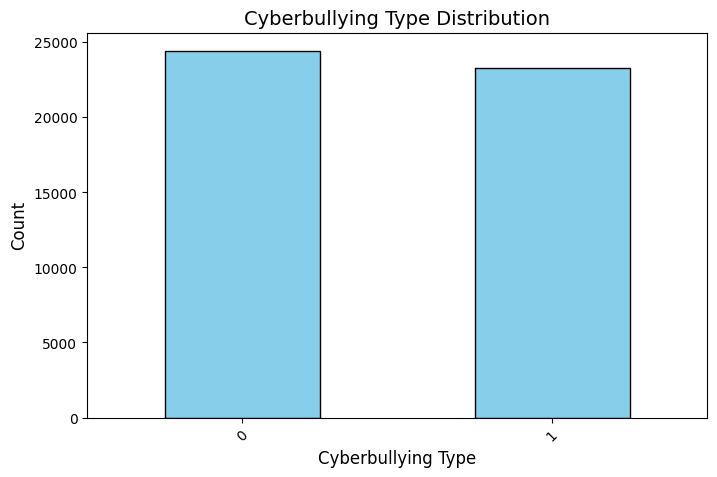

In [105]:
# Class distribution visualization
plt.figure(figsize=(8, 5))
df['cyberbullying_label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Cyberbullying Type Distribution", fontsize=14)
plt.xlabel("Cyberbullying Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()

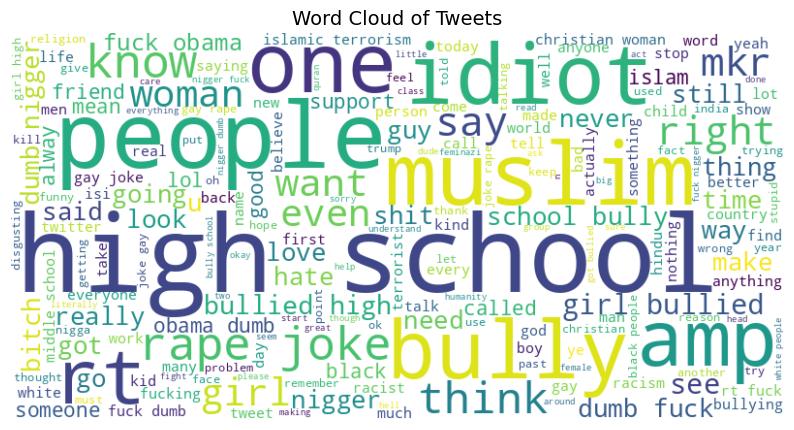

In [106]:
# Generate a word cloud for the cleaned tweets
all_text = ' '.join(df['cleaned_tweet'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Tweets", fontsize=14)
plt.show()

<ipython-input-107-50cbf4035b85>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['cyberbullying_label'], y=df['tweet_length'], palette="coolwarm")


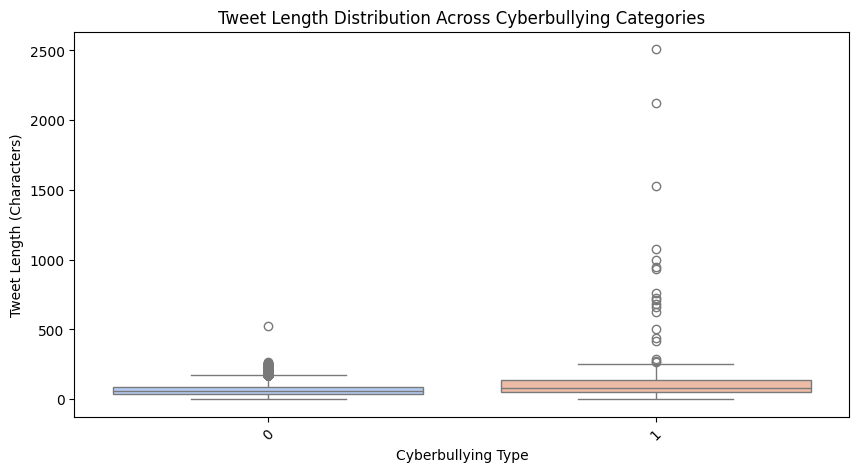

In [107]:
# Visualizing the length of tweets across categories
df['tweet_length'] = df['cleaned_tweet'].apply(len)

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['cyberbullying_label'], y=df['tweet_length'], palette="coolwarm")
plt.xticks(rotation=45)
plt.xlabel("Cyberbullying Type")
plt.ylabel("Tweet Length (Characters)")
plt.title("Tweet Length Distribution Across Cyberbullying Categories")
plt.show()

<ipython-input-108-1e9700d5cd0d>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freq_df['Word'], y=word_freq_df['Count'], palette="viridis")


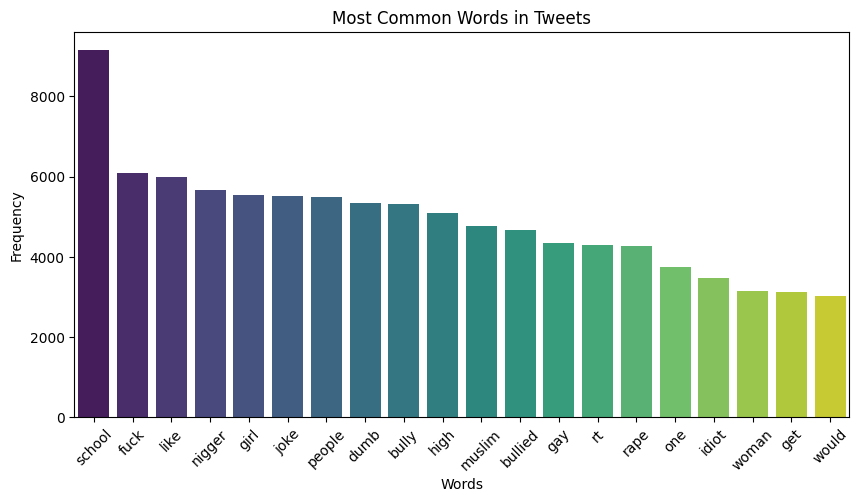

In [108]:
# Tokenize all tweets
all_words = ' '.join(df['cleaned_tweet']).split()
word_counts = Counter(all_words)

# Get top 20 words
most_common_words = word_counts.most_common(20)

# Convert to DataFrame for visualization
word_freq_df = pd.DataFrame(most_common_words, columns=['Word', 'Count'])

plt.figure(figsize=(10, 5))
sns.barplot(x=word_freq_df['Word'], y=word_freq_df['Count'], palette="viridis")
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Most Common Words in Tweets")
plt.show()

# **Feature Engineering and Transformation**

----------------------------------------------

Clean Data & Prepare Labels

In [109]:
# Remove rows with missing values in the key columns
df = df.dropna(subset=['cleaned_tweet', 'cyberbullying_label'])

# Print class distribution before splitting
print("Class Distribution Before Splitting:")
print(df['cyberbullying_label'].value_counts())

# Encode labels (if needed) to create a new column; here we convert to categorical codes.
df['cyberbullying_type_encoded'] = df['cyberbullying_label'].astype('category').cat.codes

# Remove exact duplicate tweets to avoid data leakage
df_unique = df.drop_duplicates(subset=['cleaned_tweet'], keep='first')

Class Distribution Before Splitting:
cyberbullying_label
0    24413
1    23279
Name: count, dtype: int64


Train-Test Split (Ensuring Uniqueness & Stratification)

In [110]:
X = df_unique['cleaned_tweet']
y = df_unique['cyberbullying_type_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"New Train Set Size: {len(X_train)}, New Test Set Size: {len(X_test)}")
print("\nTraining Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])
print("\nTraining Set Class Distribution:")
print(y_train.value_counts())
print("\nTesting Set Class Distribution:")
print(y_test.value_counts())

New Train Set Size: 35839, New Test Set Size: 8960

Training Set Size: 35839
Testing Set Size: 8960

Training Set Class Distribution:
cyberbullying_type_encoded
1    18147
0    17692
Name: count, dtype: int64

Testing Set Class Distribution:
cyberbullying_type_encoded
1    4537
0    4423
Name: count, dtype: int64


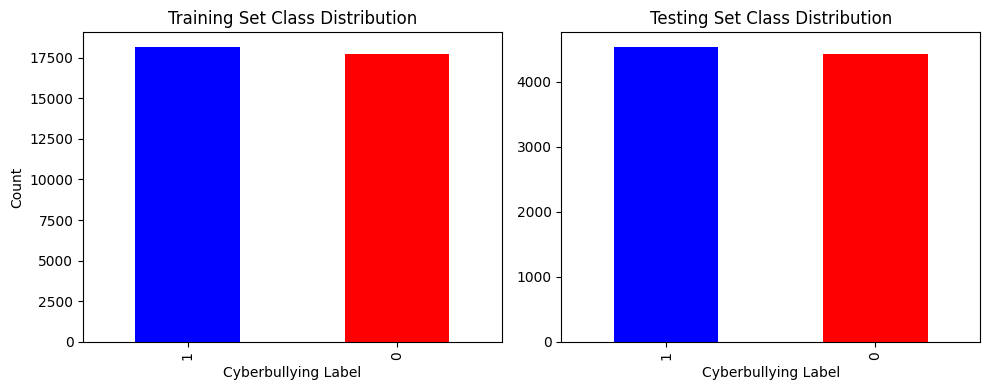

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=ax[0], color=['blue', 'red'])
ax[0].set_title("Training Set Class Distribution")
ax[0].set_xlabel("Cyberbullying Label")
ax[0].set_ylabel("Count")

y_test.value_counts().plot(kind='bar', ax=ax[1], color=['blue', 'red'])
ax[1].set_title("Testing Set Class Distribution")
ax[1].set_xlabel("Cyberbullying Label")
plt.tight_layout()
plt.show()

Feature Engineering – Text Vectorization

In [112]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=3000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print("TF-IDF Feature Count:", X_train_tfidf.shape[1])

# Bag-of-Words (BoW) Vectorization
#bow_vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=3000, stop_words='english')
#X_train_bow = bow_vectorizer.fit_transform(X_train)
#X_test_bow = bow_vectorizer.transform(X_test)
#print("BoW Feature Count:", X_train_bow.shape[1])'''

TF-IDF Feature Count: 3000


In [113]:
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# Example using Chi-Square
selector_chi2 = SelectKBest(score_func=chi2, k=1000)
X_train_selected_chi2 = selector_chi2.fit_transform(X_train_tfidf, y_train)
X_test_selected_chi2 = selector_chi2.transform(X_test_tfidf)

print("Original TF-IDF feature count:", X_train_tfidf.shape[1])
print("Reduced feature count (Chi-Square):", X_train_selected_chi2.shape[1])


Original TF-IDF feature count: 3000
Reduced feature count (Chi-Square): 1000


In [114]:
with open("Chi_Square.pkl", "wb") as f:
    pickle.dump(selector_chi2, f)

print("Model saved as 'Chi_Square.pkl'")

Model saved as 'Chi_Square.pkl'


Feature Engineering – Word2Vec Embeddings

In [115]:
'''sentences = [tweet.split() for tweet in X_train]
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

def sentence_to_vector(sentence, model, vector_size=100):
    """Convert a sentence into the average of its word vectors."""
    words = sentence.split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(vector_size)'''

'sentences = [tweet.split() for tweet in X_train]\nword2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)\n\ndef sentence_to_vector(sentence, model, vector_size=100):\n    """Convert a sentence into the average of its word vectors."""\n    words = sentence.split()\n    word_vectors = [model.wv[word] for word in words if word in model.wv]\n    if word_vectors:\n        return np.mean(word_vectors, axis=0)\n    else:\n        return np.zeros(vector_size)'

In [116]:
'''X_train_w2v = np.array([sentence_to_vector(tweet, word2vec_model) for tweet in X_train])
X_test_w2v = np.array([sentence_to_vector(tweet, word2vec_model) for tweet in X_test])
print("Word2Vec - X_train Shape:", X_train_w2v.shape)
print("Word2Vec - X_test Shape:", X_test_w2v.shape)'''

'X_train_w2v = np.array([sentence_to_vector(tweet, word2vec_model) for tweet in X_train])\nX_test_w2v = np.array([sentence_to_vector(tweet, word2vec_model) for tweet in X_test])\nprint("Word2Vec - X_train Shape:", X_train_w2v.shape)\nprint("Word2Vec - X_test Shape:", X_test_w2v.shape)'

Feature Engineering – Sentiment & Offensive Word Count

In [117]:
'''X_train_sentiment = np.array(df_unique.loc[X_train.index, 'sentiment_score']).reshape(-1, 1)
X_test_sentiment  = np.array(df_unique.loc[X_test.index, 'sentiment_score']).reshape(-1, 1)

X_train_offensive = np.array(df_unique.loc[X_train.index, 'offensive_word_count']).reshape(-1, 1)
X_test_offensive  = np.array(df_unique.loc[X_test.index, 'offensive_word_count']).reshape(-1, 1)

print("Sentiment Feature - X_train Shape:", X_train_sentiment.shape)
print("Sentiment Feature - X_test Shape:", X_test_sentiment.shape)
print("Offensive Count Feature - X_train Shape:", X_train_offensive.shape)
print("Offensive Count Feature - X_test Shape:", X_test_offensive.shape)'''

'X_train_sentiment = np.array(df_unique.loc[X_train.index, \'sentiment_score\']).reshape(-1, 1)\nX_test_sentiment  = np.array(df_unique.loc[X_test.index, \'sentiment_score\']).reshape(-1, 1)\n\nX_train_offensive = np.array(df_unique.loc[X_train.index, \'offensive_word_count\']).reshape(-1, 1)\nX_test_offensive  = np.array(df_unique.loc[X_test.index, \'offensive_word_count\']).reshape(-1, 1)\n\nprint("Sentiment Feature - X_train Shape:", X_train_sentiment.shape)\nprint("Sentiment Feature - X_test Shape:", X_test_sentiment.shape)\nprint("Offensive Count Feature - X_train Shape:", X_train_offensive.shape)\nprint("Offensive Count Feature - X_test Shape:", X_test_offensive.shape)'

In [118]:
'''# Convert the sentiment and offensive features to sparse matrices
X_train_sentiment = csr_matrix(X_train_sentiment)
X_test_sentiment  = csr_matrix(X_test_sentiment)
X_train_offensive = csr_matrix(X_train_offensive)
X_test_offensive  = csr_matrix(X_test_offensive)'''

'# Convert the sentiment and offensive features to sparse matrices\nX_train_sentiment = csr_matrix(X_train_sentiment)\nX_test_sentiment  = csr_matrix(X_test_sentiment)\nX_train_offensive = csr_matrix(X_train_offensive)\nX_test_offensive  = csr_matrix(X_test_offensive)'

Stack All Features Together

In [119]:
'''X_train_combined = hstack([X_train_tfidf,
                           X_train_sentiment,
                           #X_train_offensive
                           ])

X_test_combined = hstack([X_test_tfidf,
                          X_test_sentiment,
                          #X_test_offensive
                          ])

print("Final Combined Training Features Shape:", X_train_combined.shape)
print("Final Combined Testing Features Shape:", X_test_combined.shape)
print("Total Number of Combined Features:", X_train_combined.shape[1])

# Optional: Check unique offensive counts in the training set
print("Unique Offensive Word Counts in Training Set:",
      np.unique(X_train_offensive.toarray()))'''


'X_train_combined = hstack([X_train_tfidf,\n                           X_train_sentiment,\n                           #X_train_offensive\n                           ])\n\nX_test_combined = hstack([X_test_tfidf,\n                          X_test_sentiment,\n                          #X_test_offensive\n                          ])\n\nprint("Final Combined Training Features Shape:", X_train_combined.shape)\nprint("Final Combined Testing Features Shape:", X_test_combined.shape)\nprint("Total Number of Combined Features:", X_train_combined.shape[1])\n\n# Optional: Check unique offensive counts in the training set\nprint("Unique Offensive Word Counts in Training Set:",\n      np.unique(X_train_offensive.toarray()))'

In [120]:
selector_mi = SelectKBest(score_func=mutual_info_classif, k=1000)
X_train_selected_mi = selector_mi.fit_transform(X_train_tfidf, y_train)
X_test_selected_mi = selector_mi.transform(X_test_tfidf)


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warni

In [121]:
df['cyberbullying_binary'] = df['cyberbullying_type'].apply(
    lambda x: 0 if x == 'not_cyberbullying' else 1
)
df.head(50)

,tweet_text,cyberbullying_type,detected_offensive_words,cleaned_tweet,pos_features,sentiment_score,offensive_word_count,cyberbullying_label,tweet_length,cyberbullying_type_encoded,cyberbullying_binary
0,"In other words #katandandre, your food was cra...",not_cyberbullying,[],word katandandre food crapilicious mkr,in_IN other_JJ words_NNS katandandre_VB your_P...,0.000000,0,0,38,0,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,[],aussietv white mkr theblock imacelebrityau tod...,why_WRB is_VBZ aussietv_RB so_RB white_JJ mkr_...,0.000000,0,0,93,0,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,[],classy whore red velvet cupcake,a_DT classy_JJ whore_NN or_CC more_JJR red_JJ ...,0.050000,1,1,31,1,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,[],meh p thanks head concerned another angry dude...,meh_NN p_NN thanks_NNS for_IN the_DT heads_NNS...,-0.150000,0,0,54,0,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,[],isi account pretending kurdish account like is...,this_DT is_VBZ an_DT isis_NN account_NN preten...,0.000000,0,0,53,0,0
5,"@Raja5aab @Quickieleaks Yes, the test of god i...",not_cyberbullying,[god],yes test god good bad indifferent weird whatev...,yes_RB the_DT test_NN of_IN god_NN is_VBZ that...,-0.166667,2,1,67,1,0
6,Itu sekolah ya bukan tempat bully! Ga jauh kay...,not_cyberbullying,[],itu sekolah ya bukan tempat bully ga jauh kaya...,itu_NN sekolah_NN ya_NN bukan_NN tempat_NN bul...,0.000000,0,0,53,0,0
7,Karma. I hope it bites Kat on the butt. She is...,not_cyberbullying,[],karma hope bite kat butt nasty mkr,karma_NN i_VBZ hope_VBP it_PRP bites_VBZ kat_N...,-1.000000,0,0,34,0,0
8,@stockputout everything but mostly my priest,not_cyberbullying,[],everything mostly priest,everything_NN but_CC mostly_RB my_PRP$ priest_NN,0.500000,0,0,24,0,0
9,Rebecca Black Drops Out of School Due to Bully...,not_cyberbullying,[],rebecca black drop school due bullying,rebecca_JJ black_JJ drops_VBZ out_IN of_IN sch...,-0.145833,0,0,38,0,0


# **Model Selection & Training**

# Logistic Regression

chi2

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# 1. Initialize model
lr_model = LogisticRegression(
    max_iter=500,
    random_state=42,
    class_weight='balanced',
    C=0.01
)

# 2. Train model on Chi-Square-selected TF-IDF features
lr_model.fit(X_train_selected_chi2, y_train)

# 3. Predict on both training and test sets
# 3. Predict on both training and test sets
y_train_pred = lr_model.predict(X_train_selected_chi2)
y_test_pred = lr_model.predict(X_test_selected_chi2)

# 4. Evaluate Performance

# -- Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# -- F1-score (binary classification)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
test_f1 = f1_score(y_test, y_test_pred, average='binary')

# -- Confusion Matrix
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# -- Print results
print("=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy}")
print(f"Training F1-score: {train_f1}")
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50)

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy}")
print(f"Testing F1-score: {test_f1}")
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))
print("Testing Confusion Matrix:")
print(test_cm)

=== Training Metrics ===
Training Accuracy: 0.8472055581907977
Training F1-score: 0.8260593354932978

Training Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     17692
           1       0.98      0.72      0.83     18147

    accuracy                           0.85     35839
   macro avg       0.87      0.85      0.84     35839
weighted avg       0.87      0.85      0.84     35839

Training Confusion Matrix:
[[17360   332]
 [ 5144 13003]]

=== Testing Metrics ===
Testing Accuracy: 0.8371651785714286
Testing F1-score: 0.8134509653496995

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.98      0.86      4423
           1       0.97      0.70      0.81      4537

    accuracy                           0.84      8960
   macro avg       0.86      0.84      0.83      8960
weighted avg       0.87      0.84      0.83      8960

Testing Confusion Matri

In [123]:
import pickle
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Build a pipeline that applies chi2 feature selection and then Logistic Regression.
pipeline_lr = Pipeline([
    ('chi2', SelectKBest(score_func=chi2, k=1000)),  # Select top 1000 features from TF-IDF
    ('lr', LogisticRegression(max_iter=500, random_state=42))
])

# Define the hyperparameter space for Logistic Regression.
# Note: We use the prefix 'lr__' to refer to the Logistic Regression step in the pipeline.
param_dist_lr = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear'],  # liblinear supports both l1 and l2 penalties.
    'lr__class_weight': ['balanced', None]
}

# Initialize RandomizedSearchCV with the pipeline and parameter distribution.
random_search_lr = RandomizedSearchCV(
    pipeline_lr,
    param_distributions=param_dist_lr,
    n_iter=5,           # Number of parameter settings sampled
    cv=3,               # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,          # Use all available cores
    random_state=42
)

# Fit the randomized search on the training features.
random_search_lr.fit(X_train_selected_chi2, y_train)

# Retrieve the best estimator (pipeline with best hyperparameters).
best_lr_model = random_search_lr.best_estimator_

# Evaluate the best model on the training set.
y_train_pred_best_lr = best_lr_model.predict(X_train_selected_chi2)
train_accuracy = accuracy_score(y_train, y_train_pred_best_lr)
train_f1 = f1_score(y_train, y_train_pred_best_lr, average='binary')
train_report = classification_report(y_train, y_train_pred_best_lr)
train_cm = confusion_matrix(y_train, y_train_pred_best_lr)

# Evaluate on the test set.
y_test_pred_best_lr = best_lr_model.predict(X_test_selected_chi2)
test_accuracy = accuracy_score(y_test, y_test_pred_best_lr)
test_f1 = f1_score(y_test, y_test_pred_best_lr, average='binary')
test_report = classification_report(y_test, y_test_pred_best_lr)
test_cm = confusion_matrix(y_test, y_test_pred_best_lr)

# Display the results.
print("Best CV Score: {:.4f}".format(random_search_lr.best_score_))
print("Best Hyperparameters:", random_search_lr.best_params_)

print("\n=== Training Metrics ===")
print("Training Accuracy: {:.4f}".format(train_accuracy))
print("Training F1-Score: {:.4f}".format(train_f1))
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print("Testing Accuracy: {:.4f}".format(test_accuracy))
print("Testing F1-Score: {:.4f}".format(test_f1))
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

# Save the best Logistic Regression model (pipeline) to a pickle file.
with open("best_lr_model.pkl", "wb") as f:
    pickle.dump(best_lr_model, f)

print("\nModel saved as 'best_lr_model.pkl'")

Best CV Score: 0.9774
Best Hyperparameters: {'lr__solver': 'liblinear', 'lr__penalty': 'l2', 'lr__class_weight': 'balanced', 'lr__C': 10}

=== Training Metrics ===
Training Accuracy: 0.9825
Training F1-Score: 0.9825

Training Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17692
           1       1.00      0.97      0.98     18147

    accuracy                           0.98     35839
   macro avg       0.98      0.98      0.98     35839
weighted avg       0.98      0.98      0.98     35839

Training Confusion Matrix:
[[17683     9]
 [  617 17530]]


=== Testing Metrics ===
Testing Accuracy: 0.9787
Testing F1-Score: 0.9785

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4423
           1       1.00      0.96      0.98      4537

    accuracy                           0.98      8960
   macro avg       0.98      0.98      0

-----------------------------------------------------------------------------------

TF-IDF

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# 1. Initialize model
lr_model = LogisticRegression(
    max_iter=500,
    random_state=42,
    class_weight='balanced',
    C=0.01
)

# 2. Train model on Chi-Square-selected TF-IDF features
lr_model.fit(X_train_tfidf, y_train)

# 3. Predict on both training and test sets
y_train_pred = lr_model.predict(X_train_tfidf)
y_test_pred = lr_model.predict(X_test_tfidf)

# 4. Evaluate Performance

# -- Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# -- F1-score (binary classification)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
test_f1 = f1_score(y_test, y_test_pred, average='binary')

# -- Confusion Matrix
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# -- Print results
print("=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy}")
print(f"Training F1-score: {train_f1}")
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50)

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy}")
print(f"Testing F1-score: {test_f1}")
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))
print("Testing Confusion Matrix:")
print(test_cm)

=== Training Metrics ===
Training Accuracy: 0.8498563017941348
Training F1-score: 0.829461540899439

Training Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.87     17692
           1       0.98      0.72      0.83     18147

    accuracy                           0.85     35839
   macro avg       0.88      0.85      0.85     35839
weighted avg       0.88      0.85      0.85     35839

Training Confusion Matrix:
[[17372   320]
 [ 5061 13086]]

=== Testing Metrics ===
Testing Accuracy: 0.840625
Testing F1-score: 0.817810665986221

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.98      0.86      4423
           1       0.97      0.71      0.82      4537

    accuracy                           0.84      8960
   macro avg       0.87      0.84      0.84      8960
weighted avg       0.87      0.84      0.84      8960

Testing Confusion Matrix:
[[4327   

Hyperparameter tuning for Logistic Regression

In [125]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Define the hyperparameter space for Logistic Regression.
# Note: 'solver' is fixed to 'liblinear' here since it supports both L1 and L2 penalties.
param_dist_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced', None],
    'max_iter': [500, 1000]
}

# Initialize the Logistic Regression model.
lr_model = LogisticRegression(random_state=42, solver='liblinear')

# Initialize RandomizedSearchCV with the Logistic Regression model and hyperparameter space.
random_search_lr = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_dist_lr,
    n_iter=5,          # number of parameter settings that are sampled
    cv=3,              # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,         # use all available cores
    random_state=42
)

# Fit the randomized search on the training TF-IDF features.
random_search_lr.fit(X_train_tfidf, y_train)

# Retrieve the best estimator from the randomized search.
best_lr_model = random_search_lr.best_estimator_

# Evaluate on the training set.
y_train_pred = best_lr_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Evaluate on the test set.
y_test_pred = best_lr_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the best hyperparameters and results.
print("Best CV Score: {:.4f}".format(random_search_lr.best_score_))
print("Best Hyperparameters:", random_search_lr.best_params_)

print("\n=== Training Metrics ===")
print("Training Accuracy:", train_accuracy)
print("Training F1-score:", train_f1)
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print("Testing Accuracy:", test_accuracy)
print("Testing F1-score:", test_f1)
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)


Best CV Score: 0.9779
Best Hyperparameters: {'penalty': 'l1', 'max_iter': 1000, 'class_weight': 'balanced', 'C': 1}

=== Training Metrics ===
Training Accuracy: 0.9819470409330617
Training F1-score: 0.9818589653722136

Training Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17692
           1       1.00      0.96      0.98     18147

    accuracy                           0.98     35839
   macro avg       0.98      0.98      0.98     35839
weighted avg       0.98      0.98      0.98     35839

Training Confusion Matrix:
[[17683     9]
 [  638 17509]]


=== Testing Metrics ===
Testing Accuracy: 0.9793526785714286
Testing F1-score: 0.9791877601529981

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4423
           1       1.00      0.96      0.98      4537

    accuracy                           0.98      8960
   macro avg  

In [126]:
with open("tfidf_vectorizer.pkl", "wb") as f:
  pickle.dump(tfidf_vectorizer, f)
print("TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'")

TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'


In [127]:
# Optionally, save the best model to a pickle file.
with open("best_lr_model.pkl", "wb") as f:
    pickle.dump(best_lr_model, f)

print("Model saved as 'best_lr_model.pkl'")

Model saved as 'best_lr_model.pkl'


# Random Forest

chi2

In [128]:
import pickle
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Build a pipeline that applies Chi-Square feature selection and then trains a RandomForestClassifier.
pipeline_rf = Pipeline([
    ('chi2', SelectKBest(score_func=chi2, k=1000)),  # Select top 1000 features from TF-IDF
    ('rf', RandomForestClassifier(random_state=42))   # Default RandomForest parameters; adjust if needed
])

# Train the model using the training TF-IDF features after chi2 selection.
pipeline_rf.fit(X_train_selected_chi2, y_train)

# Predict on the training set.
y_train_pred = pipeline_rf.predict(X_train_selected_chi2)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Predict on the test set.
y_test_pred = pipeline_rf.predict(X_test_selected_chi2)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the evaluation results.
print("=== Training Metrics ===")
print("Training Accuracy: {:.4f}".format(train_accuracy))
print("Training F1-Score: {:.4f}".format(train_f1))
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print("Testing Accuracy: {:.4f}".format(test_accuracy))
print("Testing F1-Score: {:.4f}".format(test_f1))
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

=== Training Metrics ===
Training Accuracy: 0.9981
Training F1-Score: 0.9981

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17692
           1       1.00      1.00      1.00     18147

    accuracy                           1.00     35839
   macro avg       1.00      1.00      1.00     35839
weighted avg       1.00      1.00      1.00     35839

Training Confusion Matrix:
[[17692     0]
 [   68 18079]]


=== Testing Metrics ===
Testing Accuracy: 0.9792
Testing F1-Score: 0.9791

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4423
           1       1.00      0.96      0.98      4537

    accuracy                           0.98      8960
   macro avg       0.98      0.98      0.98      8960
weighted avg       0.98      0.98      0.98      8960

Testing Confusion Matrix:
[[4407   16]
 [ 170 4367]]


In [129]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Build a pipeline that applies chi2 feature selection and then RandomForestClassifier.
pipeline_rf = Pipeline([
    ('chi2', SelectKBest(score_func=chi2, k=1000)),  # Select top 1000 features from TF-IDF
    ('rf', RandomForestClassifier(random_state=42))
])

# Define optimized hyperparameter space for the Random Forest part of the pipeline.
# Note the parameter names are prefixed with 'rf__' since they belong to the 'rf' step.
param_dist_rf = {
    'rf__n_estimators': [50, 100, 150],       # Number of trees
    'rf__max_depth': [15, 20, 30],              # Maximum depth of trees
    'rf__min_samples_split': [2, 4, 6],         # Minimum samples required to split an internal node
    'rf__min_samples_leaf': [1, 2, 3],          # Minimum samples required at a leaf node
    'rf__bootstrap': [True],
    'rf__class_weight': ['balanced_subsample']  # Alternative class weighting
}

# Initialize Randomized Search CV using the pipeline and parameter distribution.
random_search_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=5,           # Number of parameter settings that are sampled
    cv=3,               # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,          # Use all available cores
    random_state=42
)

# Fit the randomized search on the training TF-IDF features.
random_search_rf.fit(X_train_selected_chi2 , y_train)

# Get the best estimator (pipeline with best hyperparameters) and predict.
best_rf_model = random_search_rf.best_estimator_

# Evaluate on the training set.
y_train_pred_best_rf = best_rf_model.predict(X_train_selected_chi2  )
train_accuracy = accuracy_score(y_train, y_train_pred_best_rf)
train_f1 = f1_score(y_train, y_train_pred_best_rf, average='binary')
train_report = classification_report(y_train, y_train_pred_best_rf)
train_cm = confusion_matrix(y_train, y_train_pred_best_rf)

# Evaluate on the test set.
y_test_pred_best_rf = best_rf_model.predict(X_test_selected_chi2) # Changed from X_train_selected_chi2 to X_test_selected_chi2
test_accuracy = accuracy_score(y_test, y_test_pred_best_rf)
test_f1 = f1_score(y_test, y_test_pred_best_rf, average='binary')
test_report = classification_report(y_test, y_test_pred_best_rf)
test_cm = confusion_matrix(y_test, y_test_pred_best_rf)

# Display the results.
print(f"Best CV Score: {random_search_rf.best_score_:.4f}")
print("Best Hyperparameters:", random_search_rf.best_params_)

print("\n=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)


Best CV Score: 0.9059
Best Hyperparameters: {'rf__n_estimators': 100, 'rf__min_samples_split': 4, 'rf__min_samples_leaf': 1, 'rf__max_depth': 20, 'rf__class_weight': 'balanced_subsample', 'rf__bootstrap': True}

=== Training Metrics ===
Training Accuracy: 0.9072
Training F1-Score: 0.8991

Training Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     17692
           1       1.00      0.82      0.90     18147

    accuracy                           0.91     35839
   macro avg       0.92      0.91      0.91     35839
weighted avg       0.92      0.91      0.91     35839

Training Confusion Matrix:
[[17690     2]
 [ 3324 14823]]


=== Testing Metrics ===
Testing Accuracy: 0.9001
Testing F1-Score: 0.8908

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      4423
           1       1.00      0.80      0.89      4537

    accuracy         

In [130]:
with open("best_rf_model.pkl", "wb") as f:
    pickle.dump(best_rf_model, f)

print("Model saved as 'best_rf_model.pkl'")

Model saved as 'best_rf_model.pkl'


In [131]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Build a pipeline with chi2 feature selection and RandomForestClassifier.
pipeline_rf = Pipeline([
    ('chi2', SelectKBest(score_func=chi2, k=1000)),  # Select top 1000 features
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))  # Parallel processing enabled
])

# Define the hyperparameter search space for Random Forest.
param_dist_rf = {
    'rf__n_estimators': [50, 100, 150],       # Number of trees
    'rf__max_depth': [10, 15, 20],            # Max depth of trees
    'rf__min_samples_split': [2, 4, 6],       # Min samples to split an internal node
    'rf__min_samples_leaf': [1, 2, 3],        # Min samples required at a leaf node
    'rf__bootstrap': [True],
    'rf__class_weight': ['balanced', 'balanced_subsample']
}

# Initialize RandomizedSearchCV with the pipeline.
random_search_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=10,          # Increased to 10 for better search coverage
    cv=3,               # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,          # Parallelize cross-validation
    random_state=42,
    verbose=2           # For monitoring progress
)

# Fit the randomized search on the training data.
random_search_rf.fit(X_train_selected_chi2, y_train)

# Get the best pipeline with optimal hyperparameters.
best_rf_model = random_search_rf.best_estimator_

# Evaluate on the training set.
y_train_pred_best_rf = best_rf_model.predict(X_train_selected_chi2)
train_accuracy = accuracy_score(y_train, y_train_pred_best_rf)
train_f1 = f1_score(y_train, y_train_pred_best_rf, average='binary')
train_report = classification_report(y_train, y_train_pred_best_rf)
train_cm = confusion_matrix(y_train, y_train_pred_best_rf)

# Evaluate on the test set.
y_test_pred_best_rf = best_rf_model.predict(X_test_selected_chi2)
test_accuracy = accuracy_score(y_test, y_test_pred_best_rf)
test_f1 = f1_score(y_test, y_test_pred_best_rf, average='binary')
test_report = classification_report(y_test, y_test_pred_best_rf)
test_cm = confusion_matrix(y_test, y_test_pred_best_rf)

# Display the results.
print(f"Best CV Score: {random_search_rf.best_score_:.4f}")
print("Best Hyperparameters:", random_search_rf.best_params_)

print("\n=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV Score: 0.9056
Best Hyperparameters: {'rf__n_estimators': 150, 'rf__min_samples_split': 4, 'rf__min_samples_leaf': 3, 'rf__max_depth': 20, 'rf__class_weight': 'balanced_subsample', 'rf__bootstrap': True}

=== Training Metrics ===
Training Accuracy: 0.9066
Training F1-Score: 0.8984

Training Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     17692
           1       1.00      0.82      0.90     18147

    accuracy                           0.91     35839
   macro avg       0.92      0.91      0.91     35839
weighted avg       0.92      0.91      0.91     35839

Training Confusion Matrix:
[[17686     6]
 [ 3343 14804]]


=== Testing Metrics ===
Testing Accuracy: 0.9009
Testing F1-Score: 0.8917

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      4423
           1   

In [132]:
with open("best_rf_model.pkl", "wb") as f:
    pickle.dump(best_rf_model, f)

print("Model saved as 'best_rf_model.pkl'")

Model saved as 'best_rf_model.pkl'


TF-IDF

In [133]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Initialize the Random Forest model using default parameters.
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the full TF-IDF training data.
rf_model.fit(X_train_tfidf, y_train)

# Predict on the training set.
y_train_pred = rf_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Predict on the test set.
y_test_pred = rf_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the evaluation results.
print("=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

=== Training Metrics ===
Training Accuracy: 0.9992
Training F1-Score: 0.9992

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17692
           1       1.00      1.00      1.00     18147

    accuracy                           1.00     35839
   macro avg       1.00      1.00      1.00     35839
weighted avg       1.00      1.00      1.00     35839

Training Confusion Matrix:
[[17692     0]
 [   30 18117]]


=== Testing Metrics ===
Testing Accuracy: 0.9771
Testing F1-Score: 0.9770

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4423
           1       1.00      0.96      0.98      4537

    accuracy                           0.98      8960
   macro avg       0.98      0.98      0.98      8960
weighted avg       0.98      0.98      0.98      8960

Testing Confusion Matrix:
[[4410   13]
 [ 192 4345]]


In [134]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define the hyperparameter space
param_dist = {
    'n_estimators': np.arange(100, 500, 200),  # Number of trees (randomly selected between 100 and 500)
    'max_depth': [None, 10, 20, 30],  # Maximum depth of trees
    'min_samples_split': np.arange(2, 4, 6),  # Min samples needed to split a node
    'min_samples_leaf': np.arange(1, 2, 3),  # Min samples at each leaf
    'max_features': ['sqrt', 'log2'],  # Number of features to consider for each split
    'bootstrap': [True]  # Whether to use bootstrap samples
}

# Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# Perform Randomized Search with 20 iterations and 5-fold cross-validation
random_search = RandomizedSearchCV(
    rf_model, param_distributions=param_dist,
    n_iter=5, cv=3, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=2
)

# Fit the model
random_search.fit(X_train_tfidf, y_train)

# Get the best parameters
best_params = random_search.best_params_
print("\nBest Hyperparameters:", best_params)

# Train the best model
best_rf = random_search.best_estimator_
best_rf.fit(X_train_tfidf, y_train)

# Predictions on training set
y_train_pred = best_rf.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')

# Predictions on testing set
y_test_pred = best_rf.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')

# Display the results
print("\n=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")

print("\n=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")


Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}

=== Training Metrics ===
Training Accuracy: 0.9992
Training F1-Score: 0.9992

=== Testing Metrics ===
Testing Accuracy: 0.9783
Testing F1-Score: 0.9782


# SVM

Train SVM model

In [135]:
import pickle
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Initialize the LinearSVC model.
svm_model = LinearSVC(random_state=42)

# Train the model on the full TF-IDF training data.
svm_model.fit(X_train_tfidf, y_train)

# Predict on the training set.
y_train_pred = svm_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Predict on the test set.
y_test_pred = svm_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the evaluation results.
print("=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

=== Training Metrics ===
Training Accuracy: 0.9838
Training F1-Score: 0.9838

Training Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17692
           1       1.00      0.97      0.98     18147

    accuracy                           0.98     35839
   macro avg       0.98      0.98      0.98     35839
weighted avg       0.98      0.98      0.98     35839

Training Confusion Matrix:
[[17683     9]
 [  570 17577]]


=== Testing Metrics ===
Testing Accuracy: 0.9799
Testing F1-Score: 0.9798

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4423
           1       1.00      0.96      0.98      4537

    accuracy                           0.98      8960
   macro avg       0.98      0.98      0.98      8960
weighted avg       0.98      0.98      0.98      8960

Testing Confusion Matrix:
[[4423    0]
 [ 180 4357]]


Hyperparameter tuning for SVM

In [136]:
import pickle
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Define the hyperparameter space for LinearSVC.
param_dist_svm = {
    'C': [0.001, 0.01, 0.1, 1, 10],          # Regularization strength
    'loss': ['hinge', 'squared_hinge'],        # Loss functions
    'dual': [False]                           # For high-dimensional data, dual=False is preferred
}

# Initialize the LinearSVC model.
svm_model = LinearSVC(random_state=42)

# Set up RandomizedSearchCV.
random_search_svm = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=param_dist_svm,
    n_iter=5,              # Number of parameter settings sampled
    cv=3,                  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,             # Use all available cores
    random_state=42
)

# Fit the randomized search on the TF-IDF training data.
random_search_svm.fit(X_train_tfidf, y_train)

# Retrieve the best estimator.
best_svm_model = random_search_svm.best_estimator_

# Evaluate on the training set.
y_train_pred = best_svm_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Evaluate on the test set.
y_test_pred = best_svm_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the results.
print("Best CV Score: {:.4f}".format(random_search_svm.best_score_))
print("Best Hyperparameters:", random_search_svm.best_params_)

print("\n=== Training Metrics ===")
print("Training Accuracy: {:.4f}".format(train_accuracy))
print("Training F1-Score: {:.4f}".format(train_f1))
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print("Testing Accuracy: {:.4f}".format(test_accuracy))
print("Testing F1-Score: {:.4f}".format(test_f1))
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/svm/_classes.py", line 321, in fit
    self.coef_, self.intercept_, n_iter_ = _fit_liblinear(
  File "/usr/local/lib/python3

Best CV Score: 0.9783
Best Hyperparameters: {'loss': 'squared_hinge', 'dual': False, 'C': 1}

=== Training Metrics ===
Training Accuracy: 0.9838
Training F1-Score: 0.9838

Training Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17692
           1       1.00      0.97      0.98     18147

    accuracy                           0.98     35839
   macro avg       0.98      0.98      0.98     35839
weighted avg       0.98      0.98      0.98     35839

Training Confusion Matrix:
[[17683     9]
 [  570 17577]]


=== Testing Metrics ===
Testing Accuracy: 0.9799
Testing F1-Score: 0.9798

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4423
           1       1.00      0.96      0.98      4537

    accuracy                           0.98      8960
   macro avg       0.98      0.98      0.98      8960
weighted avg       0.98      0.

In [137]:
# Optionally, save the best SVM model to a pickle file.
with open("best_svm_model.pkl", "wb") as f:
    pickle.dump(best_svm_model, f)

print("\nModel saved as 'best_svm_model.pkl'")


Model saved as 'best_svm_model.pkl'


# Naïve Bayes

Train Naïve Bayes model

In [138]:
import pickle
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Initialize the Multinomial Naïve Bayes model.
nb_model = MultinomialNB()

# Train the model on the full TF-IDF training data.
nb_model.fit(X_train_tfidf, y_train)

# Predict on the training set.
y_train_pred = nb_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Predict on the test set.
y_test_pred = nb_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the evaluation results.
print("=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)


=== Training Metrics ===
Training Accuracy: 0.8986
Training F1-Score: 0.8970

Training Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     17692
           1       0.92      0.87      0.90     18147

    accuracy                           0.90     35839
   macro avg       0.90      0.90      0.90     35839
weighted avg       0.90      0.90      0.90     35839

Training Confusion Matrix:
[[16385  1307]
 [ 2327 15820]]


=== Testing Metrics ===
Testing Accuracy: 0.8807
Testing F1-Score: 0.8784

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      4423
           1       0.91      0.85      0.88      4537

    accuracy                           0.88      8960
   macro avg       0.88      0.88      0.88      8960
weighted avg       0.88      0.88      0.88      8960

Testing Confusion Matrix:
[[4029  394]
 [ 675 3862]]


Hyperparameter tuning for Naïve Bayes

In [139]:
import pickle
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Define the hyperparameter space for Multinomial Naïve Bayes.
param_dist_nb = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],   # Smoothing parameter
    'fit_prior': [True, False]             # Whether to learn class prior probabilities
}

# Initialize the Multinomial Naïve Bayes model.
nb_model = MultinomialNB()

# Set up RandomizedSearchCV with the defined hyperparameter space.
random_search_nb = RandomizedSearchCV(
    estimator=nb_model,
    param_distributions=param_dist_nb,
    n_iter=5,             # Number of parameter settings that are sampled
    cv=3,                 # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,            # Use all available cores
    random_state=42
)

# Fit the hyperparameter search on the TF-IDF training data.
random_search_nb.fit(X_train_tfidf, y_train)

# Retrieve the best estimator from the search.
best_nb_model = random_search_nb.best_estimator_

# Evaluate the best model on the training set.
y_train_pred = best_nb_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Evaluate on the test set.
y_test_pred = best_nb_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the results.
print("Best CV Score: {:.4f}".format(random_search_nb.best_score_))
print("Best Hyperparameters:", random_search_nb.best_params_)

print("\n=== Training Metrics ===")
print("Training Accuracy: {:.4f}".format(train_accuracy))
print("Training F1-Score: {:.4f}".format(train_f1))
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print("Testing Accuracy: {:.4f}".format(test_accuracy))
print("Testing F1-Score: {:.4f}".format(test_f1))
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

Best CV Score: 0.9374
Best Hyperparameters: {'fit_prior': False, 'alpha': 0.001}

=== Training Metrics ===
Training Accuracy: 0.9478
Training F1-Score: 0.9482

Training Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     17692
           1       0.95      0.94      0.95     18147

    accuracy                           0.95     35839
   macro avg       0.95      0.95      0.95     35839
weighted avg       0.95      0.95      0.95     35839

Training Confusion Matrix:
[[16843   849]
 [ 1022 17125]]


=== Testing Metrics ===
Testing Accuracy: 0.9358
Testing F1-Score: 0.9366

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      4423
           1       0.94      0.94      0.94      4537

    accuracy                           0.94      8960
   macro avg       0.94      0.94      0.94      8960
weighted avg       0.94      0.94      0.94

In [140]:
# Save the best Multinomial Naïve Bayes model to a pickle file.
with open("best_nb_model.pkl", "wb") as f:
    pickle.dump(best_nb_model, f)

print("\nModel saved as 'best_nb_model.pkl'")


Model saved as 'best_nb_model.pkl'


# Decision TREE

Train Decision Tree model

In [141]:
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Initialize the Decision Tree classifier with default parameters.
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the full TF-IDF training data.
dt_model.fit(X_train_tfidf, y_train)

# Predict on the training set.
y_train_pred = dt_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Predict on the test set.
y_test_pred = dt_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the evaluation results.
print("=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

=== Training Metrics ===
Training Accuracy: 0.9992
Training F1-Score: 0.9992

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17692
           1       1.00      1.00      1.00     18147

    accuracy                           1.00     35839
   macro avg       1.00      1.00      1.00     35839
weighted avg       1.00      1.00      1.00     35839

Training Confusion Matrix:
[[17692     0]
 [   29 18118]]


=== Testing Metrics ===
Testing Accuracy: 0.9733
Testing F1-Score: 0.9735

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      4423
           1       0.98      0.97      0.97      4537

    accuracy                           0.97      8960
   macro avg       0.97      0.97      0.97      8960
weighted avg       0.97      0.97      0.97      8960

Testing Confusion Matrix:
[[4331   92]
 [ 147 4390]]


Hyperparameter tuning for Decision tree

In [142]:
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Define the hyperparameter space for Decision Tree.
param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize the Decision Tree classifier.
dt_model = DecisionTreeClassifier(random_state=42)

# Set up RandomizedSearchCV for hyperparameter tuning.
random_search_dt = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_dist_dt,
    n_iter=10,          # Number of parameter settings sampled
    cv=3,               # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,          # Use all available cores
    random_state=42
)

# Fit the hyperparameter search on the full TF-IDF training data.
# (Assuming X_train_tfidf and y_train are already defined.)
random_search_dt.fit(X_train_tfidf, y_train)

# Retrieve the best estimator (Decision Tree with best hyperparameters).
best_dt_model = random_search_dt.best_estimator_

# Evaluate the best model on the training set.
y_train_pred = best_dt_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Evaluate the best model on the test set.
y_test_pred = best_dt_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the results.
print("Best CV Score: {:.4f}".format(random_search_dt.best_score_))
print("Best Hyperparameters:", random_search_dt.best_params_)

print("\n=== Training Metrics ===")
print("Training Accuracy:", train_accuracy)
print("Training F1-Score:", train_f1)
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print("Testing Accuracy:", test_accuracy)
print("Testing F1-Score:", test_f1)
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

Best CV Score: 0.9383
Best Hyperparameters: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}

=== Training Metrics ===
Training Accuracy: 0.947068835625994
Training F1-Score: 0.9460328297914711

Training Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     17692
           1       0.98      0.92      0.95     18147

    accuracy                           0.95     35839
   macro avg       0.95      0.95      0.95     35839
weighted avg       0.95      0.95      0.95     35839

Training Confusion Matrix:
[[17315   377]
 [ 1520 16627]]


=== Testing Metrics ===
Testing Accuracy: 0.9331473214285714
Testing F1-Score: 0.9317689941906823

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.93      4423
           1       0.96      0.90      0.93      4537

    accuracy              

In [143]:
with open("best_dt_model.pkl", "wb") as f:
    pickle.dump(best_dt_model, f)

print("\nModel saved as 'dt_model.pkl'")


Model saved as 'dt_model.pkl'


# KNN

In [144]:
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Initialize the KNN model with default parameters.
knn_model = KNeighborsClassifier()

# Train the model on the full TF-IDF training data.
knn_model.fit(X_train_tfidf, y_train)

# Predict on the training set.
y_train_pred = knn_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Predict on the test set.
y_test_pred = knn_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the evaluation results.
print("=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

=== Training Metrics ===
Training Accuracy: 0.6751
Training F1-Score: 0.5332

Training Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.99      0.75     17692
           1       0.98      0.37      0.53     18147

    accuracy                           0.68     35839
   macro avg       0.79      0.68      0.64     35839
weighted avg       0.79      0.68      0.64     35839

Training Confusion Matrix:
[[17544   148]
 [11497  6650]]


=== Testing Metrics ===
Testing Accuracy: 0.6460
Testing F1-Score: 0.4743

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.99      0.73      4423
           1       0.96      0.32      0.47      4537

    accuracy                           0.65      8960
   macro avg       0.77      0.65      0.60      8960
weighted avg       0.77      0.65      0.60      8960

Testing Confusion Matrix:
[[4357   66]
 [3106 1431]]


Hyperparameter tuning for KNN

In [145]:
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Define the hyperparameter space for KNN.
param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize the KNN model.
knn_model = KNeighborsClassifier()

# Set up RandomizedSearchCV for hyperparameter tuning.
random_search_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist_knn,
    n_iter=5,           # Number of parameter settings to sample.
    cv=3,               # 3-fold cross-validation.
    scoring='accuracy',
    n_jobs=-1,          # Use all available cores.
    random_state=42
)

# Fit the hyperparameter search on the full TF-IDF training data.
random_search_knn.fit(X_train_tfidf, y_train)

# Retrieve the best estimator.
best_knn_model = random_search_knn.best_estimator_

# Evaluate the best model on the training set.
y_train_pred = best_knn_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Evaluate the best model on the test set.
y_test_pred = best_knn_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the results.
print("Best CV Score: {:.4f}".format(random_search_knn.best_score_))
print("Best Hyperparameters:", random_search_knn.best_params_)

print("\n=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

# Save the best KNN model (after hyperparameter tuning) to a pickle file.
with open("best_knn_model_tuned.pkl", "wb") as f:
    pickle.dump(best_knn_model, f)

print("\nModel saved as 'best_knn_model_tuned.pkl'")


Best CV Score: 0.6297
Best Hyperparameters: {'weights': 'distance', 'n_neighbors': 5, 'metric': 'minkowski'}

=== Training Metrics ===
Training Accuracy: 0.9992
Training F1-Score: 0.9992

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17692
           1       1.00      1.00      1.00     18147

    accuracy                           1.00     35839
   macro avg       1.00      1.00      1.00     35839
weighted avg       1.00      1.00      1.00     35839

Training Confusion Matrix:
[[17692     0]
 [   29 18118]]


=== Testing Metrics ===
Testing Accuracy: 0.6489
Testing F1-Score: 0.4810

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.98      0.73      4423
           1       0.96      0.32      0.48      4537

    accuracy                           0.65      8960
   macro avg       0.77      0.65      0.61      8960
weighted avg   

In [146]:
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Define the hyperparameter space for KNN.
param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9, 11,13,15,17,19,21,23,25],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize the KNN model.
knn_model = KNeighborsClassifier()

# Set up RandomizedSearchCV for hyperparameter tuning.
random_search_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist_knn,
    n_iter=5,           # Number of parameter settings to sample.
    cv=3,               # 3-fold cross-validation.
    scoring='accuracy',
    n_jobs=-1,          # Use all available cores.
    random_state=42
)

# Fit the hyperparameter search on the full TF-IDF training data.
random_search_knn.fit(X_train_tfidf, y_train)

# Retrieve the best estimator.
best_knn_model = random_search_knn.best_estimator_

# Evaluate the best model on the training set.
y_train_pred = best_knn_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='binary')
train_report = classification_report(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

# Evaluate the best model on the test set.
y_test_pred = best_knn_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
test_report = classification_report(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Display the results.
print("Best CV Score: {:.4f}".format(random_search_knn.best_score_))
print("Best Hyperparameters:", random_search_knn.best_params_)

print("\n=== Training Metrics ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")
print("\nTraining Classification Report:")
print(train_report)
print("Training Confusion Matrix:")
print(train_cm)

print("\n" + "="*50 + "\n")

print("=== Testing Metrics ===")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Testing F1-Score: {test_f1:.4f}")
print("\nTesting Classification Report:")
print(test_report)
print("Testing Confusion Matrix:")
print(test_cm)

Best CV Score: 0.6415
Best Hyperparameters: {'weights': 'uniform', 'n_neighbors': 3, 'metric': 'euclidean'}

=== Training Metrics ===
Training Accuracy: 0.7200
Training F1-Score: 0.6237

Training Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.99      0.78     17692
           1       0.98      0.46      0.62     18147

    accuracy                           0.72     35839
   macro avg       0.81      0.72      0.70     35839
weighted avg       0.81      0.72      0.70     35839

Training Confusion Matrix:
[[17488   204]
 [ 9831  8316]]


=== Testing Metrics ===
Testing Accuracy: 0.6614
Testing F1-Score: 0.5150

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.98      0.74      4423
           1       0.94      0.36      0.52      4537

    accuracy                           0.66      8960
   macro avg       0.77      0.67      0.63      8960
weighted avg    

In [147]:
# Save the best KNN model (after hyperparameter tuning) to a pickle file.
with open("best_knn_model_tuned.pkl", "wb") as f:
    pickle.dump(best_knn_model, f)

print("\nModel saved as 'best_knn_model_tuned.pkl'")


Model saved as 'best_knn_model_tuned.pkl'


# **GUI**

In [148]:
!pip install gradio scikit-learn numpy pickle5 gensim

In [149]:
!pip install gradio scikit-learn numpy gensim

In [151]:
import gradio as gr
import pickle
import numpy as np
import os

# ---------------------------
# Load Models and Vectorizers
# ---------------------------
model_paths = {
    "Logistic Regression": "/content/best_lr_model.pkl",
    "Random Forest": "/content/best_rf_model.pkl",
    "SVM": "/content/best_svm_model.pkl",
    "Naive Bayes": "/content/best_nb_model.pkl",
    "Decision Tree": "/content/best_dt_model.pkl",
    "KNN": "/content/best_knn_model_tuned.pkl",
}

models = {}
for name, path in model_paths.items():
    if os.path.exists(path):
        with open(path, 'rb') as f:
            models[name] = pickle.load(f)
    else:
        print(f"Warning: Model file not found - {path}")

vectorizer_paths = {
    "TF-IDF": "/content/tfidf_vectorizer.pkl",
    "chi2": "/content/Chi_Square.pkl",
}

vectorizers = {}
for name, path in vectorizer_paths.items():
    if os.path.exists(path):
        with open(path, 'rb') as f:
            vectorizers[name] = pickle.load(f)
    else:
        print(f"Warning: Vectorizer file not found - {path}")

# Mapping of models to their vectorizers.
vectorizer_mapping = {
    "Logistic Regression": "TF-IDF",
    "Random Forest": "chi2",
    "SVM": "TF-IDF",
    "Naive Bayes": "TF-IDF",
    "Decision Tree": "TF-IDF",
    "KNN": "TF-IDF",
}

# ---------------------------
# Prediction and Clear Functions
# ---------------------------
def predict(text, model_name):
    if model_name not in models:
        return "Error: Model not loaded."

    # Retrieve the appropriate vectorizer (TF-IDF in our case)
    vectorizer_name = vectorizer_mapping.get(model_name, "TF-IDF")
    if vectorizer_name not in vectorizers:
        return f"Error: Vectorizer '{vectorizer_name}' not found."

    # Transform text using the loaded vectorizer.
    text_vectorized = vectorizers[vectorizer_name].transform([text])

    # Check for matching feature count.
    if text_vectorized.shape[1] != models[model_name].n_features_in_:
        return f"Error: Expected {models[model_name].n_features_in_} features, got {text_vectorized.shape[1]}"

    # Make prediction.
    prediction = models[model_name].predict(text_vectorized)
    return "Cyberbullying" if prediction[0] == 1 else "Non-Cyberbullying"

def clear():
    # Return empty values for the text input, model dropdown, and output.
    return "", None, ""

# ---------------------------
# Custom CSS for GUI Enhancement
# ---------------------------
custom_css = """
/* Global Styles */
body {
    background-color: #f5f5f5;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
}

/* Header styling */
.header {
    text-align: center;
    padding: 20px;
    background-color: #4CAF50;
    color: white;
    border-radius: 10px;
    margin-bottom: 20px;
}

/* Instruction styling */
.instructions {
    text-align: center;
    padding: 10px;
    font-size: 14px;
    color: #333;
}

/* Input and output elements */
input, textarea, select {
    border: 2px solid #4CAF50 !important;
    border-radius: 5px !important;
    padding: 10px !important;
    font-size: 16px !important;
}

/* Button styling */
button {
    background-color: #4CAF50 !important;
    color: white !important;
    border: none !important;
    padding: 10px 20px !important;
    margin: 5px !important;
    border-radius: 5px !important;
    cursor: pointer !important;
    font-size: 16px !important;
}

button:hover {
    background-color: #45a049 !important;
}
"""

# ---------------------------
# Gradio Interface with Enhanced Styling
# ---------------------------
with gr.Blocks(css=custom_css) as demo:
    # Custom HTML header
    gr.HTML("""
    <div class="header">
      <h1>Cyberbullying Detection</h1>
      <p>Enter text and select a model to detect cyberbullying.</p>
    </div>
    """)

    # Additional instructions for the user
    gr.HTML("""
    <div class="instructions">
      <p><strong>Instructions:</strong> Type or paste the text you want to analyze in the box below,
      choose a model from the dropdown, and click <em>Predict</em>.<br>
      You can also select one of the example texts to see how the model responds.</p>
    </div>
    """)

    # Input row: text and model selector
    with gr.Row():
        with gr.Column(scale=2):
            text_input = gr.Textbox(label="Enter Text", placeholder="Type the text to analyze here...", lines=4)
        with gr.Column(scale=1):
            model_dropdown = gr.Dropdown(choices=list(models.keys()), label="Select Model")

    # Examples row: sample inputs
    gr.Examples(
        examples=[
            ["You are so stupid and worthless."],
            ["I really enjoy our conversation, you are amazing!"],
            ["Nobody likes you, Your so fat!"],
        ],
        inputs=text_input,
        label="Example Inputs",
        cache_examples=False
    )

    # Output for prediction
    output_text = gr.Textbox(label="Prediction", placeholder="The prediction will appear here...", lines=2)

    # Buttons row
    with gr.Row():
        predict_button = gr.Button("Predict")
        clear_button = gr.Button("Clear")

    # Link button actions to functions
    predict_button.click(fn=predict, inputs=[text_input, model_dropdown], outputs=output_text)
    clear_button.click(fn=clear, inputs=[], outputs=[text_input, model_dropdown, output_text])

# Launch the Gradio GUI (set share=True if you need a public link)
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5e686383aefdf4fa1b.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
